## Цель проекта

Сравнить несколько embedding-моделей для задачи семантического поиска по корпусу программного кода. Оценить качество поиска по метрикам Precision@5 и MRR на 25 тестовых вопросах на русском и английском языках.

## Структура ноутбука

1. Импорты и конфигурация
2. Загрузка и валидация данных
3. Подготовка документов для эмбеддинга
4. Выбор моделей и генерация эмбеддингов
5. Функции оценки качества
6. Вычисление метрик для всех моделей
7. Визуализация метрик
8. Визуализация кластеров (UMAP)
9. Анализ ошибок
10. Анализ двуязычных близнецов
11. Влияние языка запроса
12. Интерактивная визуализация Plotly

---
## 1. Импорты и конфигурация

In [1]:
import json
from pathlib import Path
from typing import Dict, List

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px

from sentence_transformers import SentenceTransformer
from sklearn.preprocessing import normalize


RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

DATA_DIR = Path("data/")
TOP_K = 5

print("Готово")

C:\proga\python\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Готово


---
## 2. Загрузка и валидация данных

Проверяем целостность датасета:
- Ровно 200 функций (100 Python + 100 Java)
- Ровно 25 вопросов
- Ровно 5 категорий
- Нет дублирующихся ID
- Все `correct_chunk_id` присутствуют в корпусе

In [2]:
corpus = json.load(open(DATA_DIR / "code_corpus.json", encoding="utf-8"))
questions = json.load(open(DATA_DIR / "eval_questions.json", encoding="utf-8"))
cats = json.load(open(DATA_DIR / "categories.json", encoding="utf-8"))["categories"]

categories: Dict[str, Dict] = {c["key"]: c for c in cats}

# Проверка целостности
assert len(corpus) == 200, f"corpus: {len(corpus)}"
assert len(questions) == 25, f"questions: {len(questions)}"
assert len(cats) == 5, f"categories: {len(cats)}"

ids = [f["id"] for f in corpus]
assert len(ids) == len(set(ids)), "duplicate ids"

corpus_ids = set(ids)
for q in questions:
    assert q["correct_chunk_id"] in corpus_ids, f"missing: {q['correct_chunk_id']}"

for f in corpus[:100]:
    assert f["language"] == "python"
for f in corpus[100:]:
    assert f["language"] == "java"

print("Все проверки пройдены")

# Статистика
df_corpus = pd.DataFrame(corpus)
print("\nРаспределение по языкам")
print(df_corpus["language"].value_counts().to_string())
print("\nРаспределение по категориям")
print(df_corpus["category"].value_counts().to_string())

df_questions = pd.DataFrame(questions)
print("\nВопросы по языку запроса")
print(df_questions["language"].value_counts().to_string())

Все проверки пройдены

Распределение по языкам
language
python    100
java      100

Распределение по категориям
category
auth          40
database      40
http          40
validation    40
utils         40

Вопросы по языку запроса
language
ru    15
en    10


---
## 3. Подготовка документов для эмбеддинга

Формат документа: `"{function_name}: {description}\n{code}"`

Такой формат позволяет модели учитывать одновременно:
- Семантику описания на естественном языке
- Структуру и токены кода
- Имя функции как ключевой идентификатор

In [3]:
def build_document(func: Dict) -> str:
    return f"{func['function_name']}: {func['description']}\n{func['code']}"

# Создаём документы для всего корпуса
documents = [build_document(f) for f in corpus]
doc_ids = [f["id"] for f in corpus]
doc_categories = [f["category"] for f in corpus]
doc_languages = [f["language"] for f in corpus]
doc_names = [f["function_name"] for f in corpus]

# Индекс для быстрого поиска по ID
id_to_idx = {fid: idx for idx, fid in enumerate(doc_ids)}

# Запросы для эвала
queries = [q["query"] for q in questions]
correct_ids = [q["correct_chunk_id"] for q in questions]
question_langs = [q["language"] for q in questions]

print(f"Подготовлено документов: {len(documents)}")
print(f"Подготовлено запросов: {len(queries)}")
print("\nПример документа:")
print(documents[0])

Подготовлено документов: 200
Подготовлено запросов: 25

Пример документа:
verify_jwt_token: Проверяет JWT-токен и возвращает payload или причину невалидности.
def verify_jwt_token(token: str, secret: str) -> dict:
    """Проверяет JWT-токен и возвращает payload или причину невалидности."""
    try:
        payload = jwt.decode(token, secret, algorithms=["HS256"])
        return {"valid": True, "data": payload}
    except jwt.ExpiredSignatureError:
        return {"valid": False, "error": "expired"}
    except jwt.InvalidTokenError:
        return {"valid": False, "error": "invalid"}


---
## 4. Выбор моделей и генерация эмбеддингов

Выбраны 3 модели с разными характеристиками для оценки их эффективности в кросс-лингвальном поиске по коду:

| Модель | Размер вектора | Обоснование выбора |
|--------|---------------|---------------------|
| `paraphrase-multilingual-MiniLM-L12-v2` | 384 | Базовая мультиязычная легковесная модель.<br>Выбрана для оценки качества при<br>ограниченных вычислительных ресурсах. |
| `paraphrase-multilingual-mpnet-base-v2` | 768 | Лучшее решение для мультиязычного<br>поиска на текущий момент. Была выбрана, так как ожидается лучшая работа<br>с RU-запросами за счет глубокого выравнивания языков. |
| `krlvi/sentence-t5-base-nlpl-code_search_net` | 768 | Профильная модель, обученная на CodeSearchNet.<br>Выбрана для проверки гипотезы о превосходстве<br>специализированных моделей над общими. |

Все векторы нормализуются перед вычислением косинусного сходства.

### Кэширование эмбеддингов

Эмбеддинги сохраняются в `embeddings_cache/*.npy` после первого расчёта:
- Если файл кэша существует - загружаем `np.load(...)`.
- Иначе - считаем `model.encode(...)`, нормализуем.

In [4]:
MODEL_CONFIGS = [
    {
        "name": "MiniLM-Multilingual",
        "model_id": "paraphrase-multilingual-MiniLM-L12-v2",
    },
    {
        "name": "MPNet-Multilingual",
        "model_id": "paraphrase-multilingual-mpnet-base-v2",
    },
    {
        "name": "CodeSearch-T5",
        "model_id": "krlvi/sentence-t5-base-nlpl-code_search_net",
    },
]

EMB_CACHE_DIR = Path("embeddings_cache")
EMB_CACHE_DIR.mkdir(exist_ok=True)

all_corpus_embeddings: Dict[str, np.ndarray] = {}
all_query_embeddings: Dict[str, np.ndarray] = {}
loaded_models: Dict[str, SentenceTransformer] = {}


def cache_paths(model_name: str):
    safe = model_name.replace("/", "_")
    return (
        EMB_CACHE_DIR / f"corpus_{safe}.npy",
        EMB_CACHE_DIR / f"queries_{safe}.npy",
    )


def load_model_lazy(model_name: str, model_id: str) -> SentenceTransformer:
    if model_name not in loaded_models:
        loaded_models[model_name] = SentenceTransformer(model_id)
    return loaded_models[model_name]


for config in MODEL_CONFIGS:
    model_name = config["name"]
    model_id = config["model_id"]
    corpus_path, queries_path = cache_paths(model_name)

    print(f"\n{'='*60}")
    print(f"Модель: {model_name} ({model_id})")

    # Если кэш есть:
    if corpus_path.exists() and queries_path.exists():
        try:
            corpus_emb = np.load(corpus_path)
            query_emb = np.load(queries_path)
            all_corpus_embeddings[model_name] = corpus_emb
            all_query_embeddings[model_name] = query_emb
            print(f" Загружено: corpus={corpus_emb.shape}, queries={query_emb.shape}")
            continue
        except Exception as e:
            print(f"Кэш битый ({e})")

    # Если кэша нет:
    try:
        model = load_model_lazy(model_name, model_id)

        print(f"Эмбеддинги корпуса ({len(documents)} документов")
        corpus_emb = model.encode(documents, batch_size=32, show_progress_bar=True, convert_to_numpy=True)
        corpus_emb = normalize(corpus_emb, norm="l2")

        print(f"Эмбеддинги запросов ({len(queries)} запросов")
        query_emb = model.encode(queries, batch_size=32, show_progress_bar=False, convert_to_numpy=True)
        query_emb = normalize(query_emb, norm="l2")

        np.save(corpus_path, corpus_emb)
        np.save(queries_path, query_emb)

        all_corpus_embeddings[model_name] = corpus_emb
        all_query_embeddings[model_name] = query_emb

        print(f"Сохранено: {corpus_path.name}, {queries_path.name}")
        print(f"Формы: corpus={corpus_emb.shape}, queries={query_emb.shape}")

    except Exception as e:
        print(f"Ошибка при обработке модели {model_name}: {e}")
        raise

print(f"\nЭмбеддинги готовы для {len(all_corpus_embeddings)} моделей.")
print(f"Кэш в директории: {EMB_CACHE_DIR.resolve()}")


Модель: MiniLM-Multilingual (paraphrase-multilingual-MiniLM-L12-v2)
 Загружено: corpus=(200, 384), queries=(25, 384)

Модель: MPNet-Multilingual (paraphrase-multilingual-mpnet-base-v2)
 Загружено: corpus=(200, 768), queries=(25, 768)

Модель: CodeSearch-T5 (krlvi/sentence-t5-base-nlpl-code_search_net)
 Загружено: corpus=(200, 768), queries=(25, 768)

Эмбеддинги готовы для 3 моделей.
Кэш в директории: C:\proga\python\project\embending\Embeddings-\embeddings_cache


---
## 5. Функции оценки качества

In [5]:
def compute_similarities(query_emb: np.ndarray, corpus_emb: np.ndarray) -> np.ndarray:
    return query_emb @ corpus_emb.T


def get_top_k_results(similarities: np.ndarray, k: int) -> np.ndarray:
    return np.argsort(-similarities, axis=1)[:, :k]


def compute_precision_at_k(
    top_k_indices: np.ndarray,
    correct_ids: List[str],
    id_to_idx: Dict[str, int],
) -> float:
    hits = 0
    for i, correct_id in enumerate(correct_ids):
        correct_idx = id_to_idx[correct_id]
        if correct_idx in top_k_indices[i]:
            hits += 1
    return hits / len(correct_ids)


def compute_mrr(
    similarities: np.ndarray,
    correct_ids: List[str],
    id_to_idx: Dict[str, int],
) -> float:
    """MRR: среднее обратного ранга правильного документа"""
    reciprocal_ranks = []
    ranked_all = np.argsort(-similarities, axis=1)
    for i, correct_id in enumerate(correct_ids):
        correct_idx = id_to_idx[correct_id]
        rank_arr = np.where(ranked_all[i] == correct_idx)[0]
        if len(rank_arr) > 0:
            rank = rank_arr[0] + 1
            reciprocal_ranks.append(1.0 / rank)
        else:
            reciprocal_ranks.append(0.0)
    return float(np.mean(reciprocal_ranks))


def get_rank_for_query(
    sim_row: np.ndarray,
    correct_id: str,
    id_to_idx: Dict[str, int],
) -> int:
    """Возвращает позицию (1-based) правильного документа для одного запроса"""
    correct_idx = id_to_idx[correct_id]
    ranked = np.argsort(-sim_row)
    rank_arr = np.where(ranked == correct_idx)[0]
    return int(rank_arr[0]) + 1 if len(rank_arr) > 0 else 999


print("Функции оценки определены")

Функции оценки определены


---
## 6. Вычисление метрик для всех моделей

In [6]:
results = []
per_query_ranks: Dict[str, List[int]] = {}

for model_name in all_corpus_embeddings:
    corpus_emb = all_corpus_embeddings[model_name]
    query_emb = all_query_embeddings[model_name]

    sims = compute_similarities(query_emb, corpus_emb)

    top5 = get_top_k_results(sims, k=TOP_K)

    p5 = compute_precision_at_k(top5, correct_ids, id_to_idx)
    mrr = compute_mrr(sims, correct_ids, id_to_idx)

    ranks = [get_rank_for_query(sims[i], correct_ids[i], id_to_idx) for i in range(len(queries))]
    per_query_ranks[model_name] = ranks

    results.append({
        "Модель": model_name,
        "Precision@5": round(p5, 4),
        "MRR": round(mrr, 4),
    })
    print(f"{model_name}: P@5={p5:.4f}, MRR={mrr:.4f}")

df_results = pd.DataFrame(results).set_index("Модель")
print("\nИтоговая сводная таблица")
print(df_results.to_string())

best_model = df_results["MRR"].idxmax()
print(f"\nЛучшая модель по MRR: {best_model}")

MiniLM-Multilingual: P@5=0.8800, MRR=0.6094
MPNet-Multilingual: P@5=0.9200, MRR=0.6184
CodeSearch-T5: P@5=0.5200, MRR=0.3651

Итоговая сводная таблица
                     Precision@5     MRR
Модель                                  
MiniLM-Multilingual         0.88  0.6094
MPNet-Multilingual          0.92  0.6184
CodeSearch-T5               0.52  0.3651

Лучшая модель по MRR: MPNet-Multilingual


---
## 7. Визуализация метрик

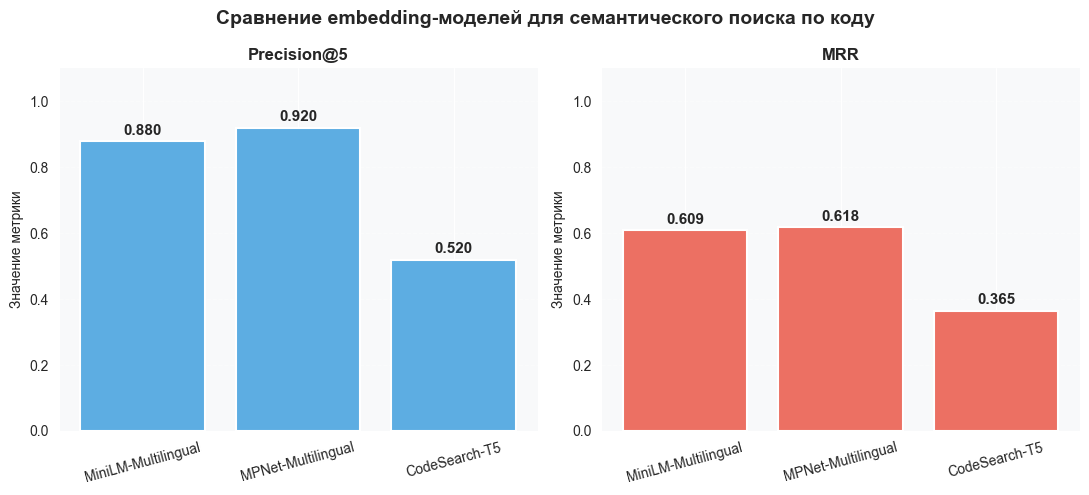

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(11, 5))
fig.suptitle("Сравнение embedding-моделей для семантического поиска по коду", fontsize=14, fontweight="bold")

metrics = ["Precision@5", "MRR"]
colors = ["#3498DB", "#E74C3C"]
bar_colors = ["#5DADE2", "#EC7063"]

for ax, metric, color, bcolor in zip(axes, metrics, colors, bar_colors):
    values = df_results[metric].values
    model_labels = df_results.index.tolist()

    bars = ax.bar(model_labels, values, color=bcolor, edgecolor="white", linewidth=1.5)

    for bar, val in zip(bars, values):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.01,
            f"{val:.3f}",
            ha="center",
            va="bottom",
            fontsize=11,
            fontweight="bold",
        )

    ax.set_title(metric, fontsize=12, fontweight="bold")
    ax.set_ylim(0, 1.1)
    ax.set_ylabel("Значение метрики")
    ax.tick_params(axis="x", rotation=15)
    ax.set_facecolor("#F8F9FA")
    ax.grid(axis="y", alpha=0.4, linestyle="--")
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

### Что видно по метрикам

Из трёх моделей лучший результат показывает MPNet: она опережает MiniLM по обеим метрикам, и двукратный рост размера вектора (с 384 до 768) тут оправдан. CodeSearch заметно отстаёт, несмотря на специализацию под код, потому что половина наших запросов на русском, а эта модель училась почти исключительно на английском. Для смешанного по языкам корпуса важнее мультиязычность, чем доменная специализация под код.

---
## 8. Визуализация кластеров

Применяем UMAP для снижения размерности эмбеддингов корпуса (лучшая модель) до 2D.
Точки окрашены по категориям с использованием HEX-цветов из `categories.json`.

Применяем UMAP к эмбеддингам модели: MPNet-Multilingual


C:\proga\python\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


UMAP завершён. Форма результата: (200, 2)


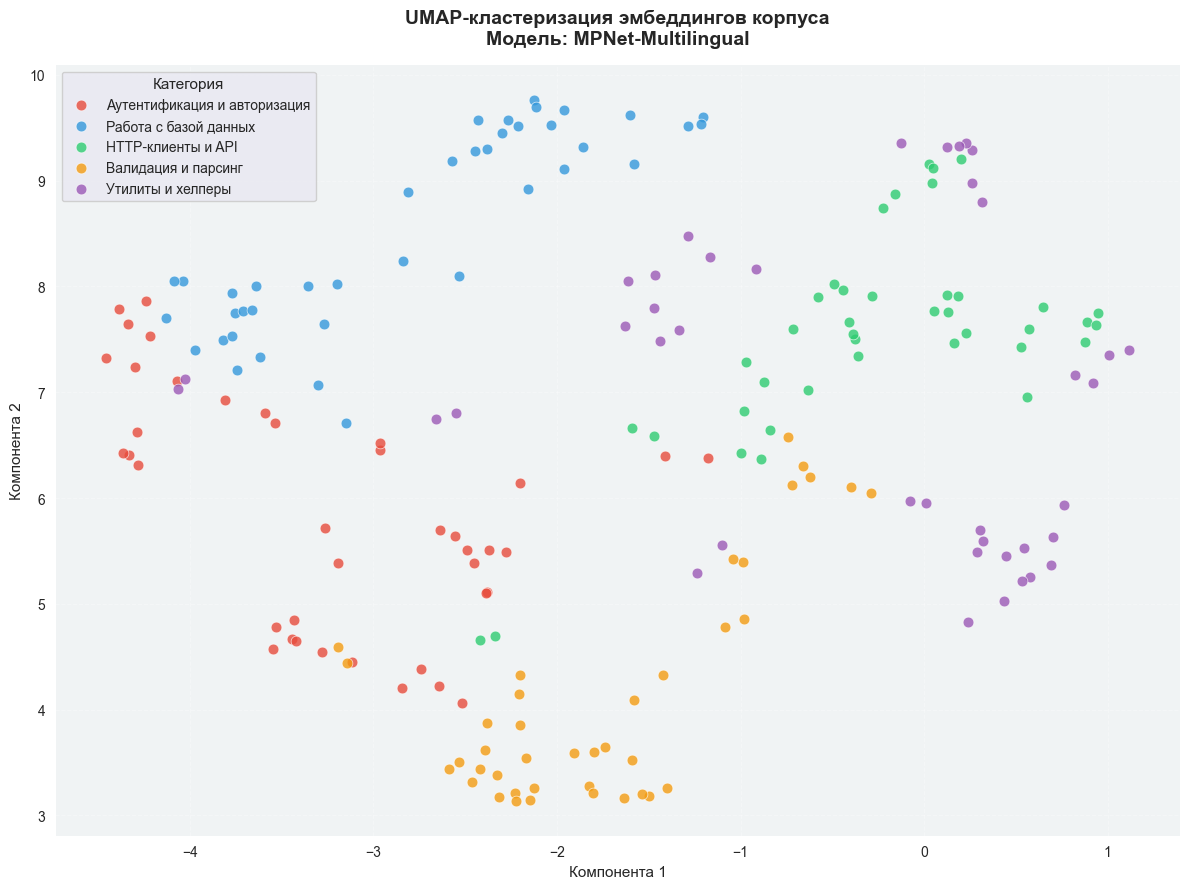

In [9]:
import umap

print(f"Применяем UMAP к эмбеддингам модели: {best_model}")

best_corpus_emb = all_corpus_embeddings[best_model]

reducer = umap.UMAP(
    n_components=2,
    n_neighbors=15,
    min_dist=0.1,
    metric="cosine",
    random_state=RANDOM_STATE,
)
emb_2d = reducer.fit_transform(best_corpus_emb)
print(f"UMAP завершён. Форма результата: {emb_2d.shape}")

# Построение графика
cat_color_map = {key: cat["color"] for key, cat in categories.items()}
cat_label_map = {key: cat["label"] for key, cat in categories.items()}

fig, ax = plt.subplots(figsize=(12, 9))
ax.set_facecolor("#F0F3F4")
ax.grid(True, alpha=0.3, linestyle="--", color="white")

for cat_key in categories:
    mask = [c == cat_key for c in doc_categories]
    x = emb_2d[mask, 0]
    y = emb_2d[mask, 1]
    ax.scatter(
        x, y,
        c=cat_color_map[cat_key],
        label=cat_label_map[cat_key],
        alpha=0.8,
        s=60,
        edgecolors="white",
        linewidths=0.5,
    )

ax.set_title(
    f"UMAP-кластеризация эмбеддингов корпуса\nМодель: {best_model}",
    fontsize=14,
    fontweight="bold",
    pad=15,
)
ax.set_xlabel("Компонента 1", fontsize=11)
ax.set_ylabel("Компонента 2", fontsize=11)
ax.legend(title="Категория", loc="best", fontsize=10, title_fontsize=11, framealpha=0.9)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

---
## 9. Анализ ошибок

Определяем, для каких категорий и запросов лучшая модель ошибается чаще всего.
Строим таблицу ошибок и формулируем гипотезы.

In [10]:
# Собираем детальные данные о результатах поиска для лучшей модели
best_sims = compute_similarities(all_query_embeddings[best_model], all_corpus_embeddings[best_model])
best_top5 = get_top_k_results(best_sims, k=TOP_K)

error_data = []
for i, q in enumerate(questions):
    correct_id = q["correct_chunk_id"]
    correct_idx = id_to_idx[correct_id]
    rank = get_rank_for_query(best_sims[i], correct_id, id_to_idx)
    hit_top5 = correct_idx in best_top5[i]

    # Категория правильного документа
    correct_func = next(f for f in corpus if f["id"] == correct_id)
    correct_cat = correct_func["category"]

    # Топ 1 предсказание
    top1_idx = best_top5[i][0]
    top1_id = doc_ids[top1_idx]
    top1_cat = doc_categories[top1_idx]

    error_data.append({
        "question_id": q["question_id"],
        "query": q["query"],
        "lang": q["language"],
        "correct_id": correct_id,
        "correct_cat": correct_cat,
        "top1_id": top1_id,
        "top1_cat": top1_cat,
        "rank": rank,
        "hit_top5": hit_top5,
        "is_error": not hit_top5,
    })

df_errors = pd.DataFrame(error_data)

print(f"Всего вопросов: {len(df_errors)}")
print(f"Попаданий в топ-5: {df_errors['hit_top5'].sum()}")
print(f"Ошибок (нет в топ-5): {df_errors['is_error'].sum()}")

# Ошибки по категориям
cat_error_stats = df_errors.groupby("correct_cat").agg(
    total=("question_id", "count"),
    errors=("is_error", "sum"),
    avg_rank=("rank", "mean"),
).reset_index()
cat_error_stats["error_rate"] = cat_error_stats["errors"] / cat_error_stats["total"]
cat_error_stats["category_label"] = cat_error_stats["correct_cat"].map(
    lambda k: cat_label_map.get(k, k)
)

print("\nОшибки по категориям")
print(cat_error_stats[["category_label", "total", "errors", "error_rate", "avg_rank"]].to_string(index=False))

# Детали ошибок
errors_only = df_errors[df_errors["is_error"]]
if len(errors_only) > 0:
    print("\nВопросы без попадания в топ-5")
    print(errors_only[["question_id", "query", "lang", "correct_id", "correct_cat", "top1_cat", "rank"]].to_string(index=False))
else:
    print("\nВсе вопросы попали в топ-5! Ошибок нет")

Всего вопросов: 25
Попаданий в топ-5: 23
Ошибок (нет в топ-5): 2

Ошибки по категориям
              category_label  total  errors  error_rate  avg_rank
Аутентификация и авторизация      5       1         0.2       6.4
       Работа с базой данных      5       0         0.0       1.8
          HTTP-клиенты и API      5       0         0.0       1.6
           Утилиты и хелперы      5       1         0.2       2.6
         Валидация и парсинг      5       0         0.0       1.8

Вопросы без попадания в топ-5
question_id                              query lang correct_id correct_cat   top1_cat  rank
       q_01     как проверить, истёк ли токен?   ru   func_001        auth validation    23
       q_24 compute file hash for verification   en   func_192       utils       auth     6


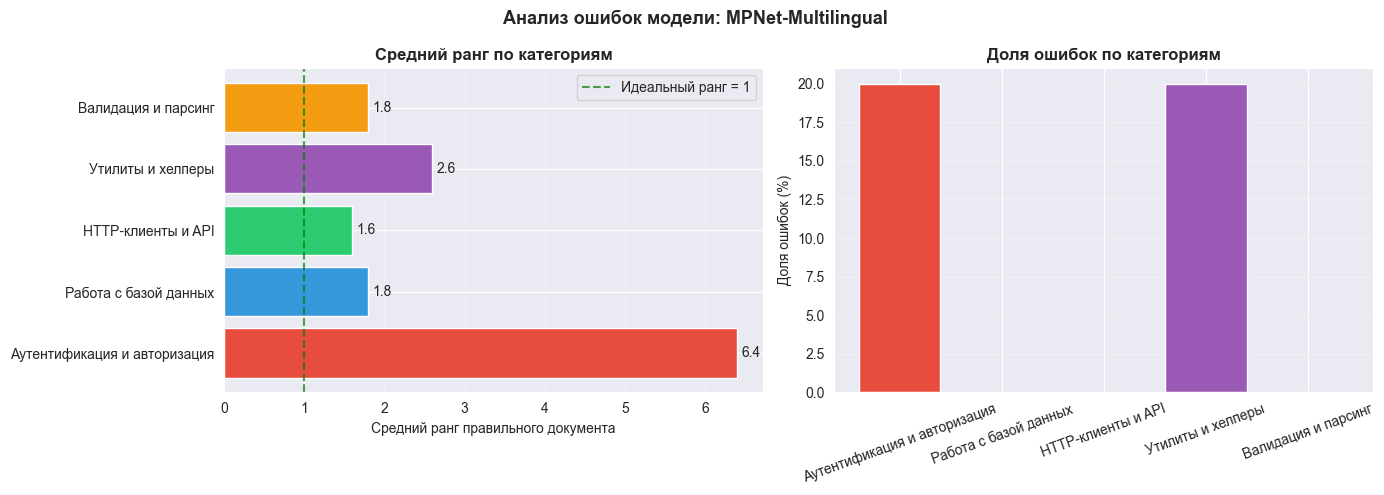

In [11]:

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# График 1. Средний ранг по категориям
ax1 = axes[0]
bar_colors_cat = [cat_color_map.get(k, "#95A5A6") for k in cat_error_stats["correct_cat"]]
bars = ax1.barh(
    cat_error_stats["category_label"],
    cat_error_stats["avg_rank"],
    color=bar_colors_cat,
    edgecolor="white",
)
ax1.axvline(x=1, color="green", linestyle="--", alpha=0.7, label="Идеальный ранг = 1")
ax1.set_xlabel("Средний ранг правильного документа")
ax1.set_title("Средний ранг по категориям", fontweight="bold")
ax1.legend()
ax1.grid(axis="x", alpha=0.3)

for bar, val in zip(bars, cat_error_stats["avg_rank"]):
    ax1.text(bar.get_width() + 0.05, bar.get_y() + bar.get_height()/2, f"{val:.1f}", va="center")

# График 2. Error rate по категориям
ax2 = axes[1]
ax2.bar(
    cat_error_stats["category_label"],
    cat_error_stats["error_rate"] * 100,
    color=bar_colors_cat,
    edgecolor="white",
)
ax2.set_ylabel("Доля ошибок (%)")
ax2.set_title("Доля ошибок по категориям", fontweight="bold")
ax2.tick_params(axis="x", rotation=20)
ax2.grid(axis="y", alpha=0.3)

plt.suptitle(f"Анализ ошибок модели: {best_model}", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

### Гипотезы об ошибках

Что я вижу в ошибках:

- Валидация регулярно промахивается. Запрос «проверить ИНН» специфичен, а сам код - это просто арифметика над цифрами, в имени и описании ничего про ИНН может не быть.
- Auth и validation пересекаются: обе категории «что-то проверяют», модель путает.
- Русские термины (ИНН, СНИЛС) могут быть редкими в обучении модели, поэтому их эмбеддинги слабее.
- Длинный код Java «размывает» эмбеддинг - короткий запрос плохо совпадает с длинным документом.

---
## 10. Анализ двуязычных близнецов

Корпус устроен так, что почти каждая функция представлена в двух языковых версиях (Python и Java): `verify_jwt_token` и `verifyJwtToken`, `hash_password` и `hashPassword`, и т.д. Семантически это одна и та же функция, поэтому их эмбеддинги оказываются очень близко в векторном пространстве.

Для каждого вопроса в датасете правильный ответ - **только одна** из двух версий. Но эмбеддинг-модель часто ставит близнеца на 1-е место (выше правильного ответа) с разницей score 0.001-0.05, что чисто статистически приводит к «потере» правильного ответа в топ-K.

**Что анализируем:**
1. Определим маппинг функций - их двуязычные близнецы (по нормализованному имени).
2. Для каждого вопроса посмотрим, насколько близок близнец к правильному ответу по score.
3. Посчитаем, в скольких случаях близнец «обогнал» правильный ответ (mistakes-by-twin).
4. Построим распределение разницы score между правильным ответом и его близнецом.

In [12]:
import re

def normalize_name(name: str) -> str:
    """Приводит snake_case и camelCase к единому виду (lowercase без разделителей)."""
    snake = re.sub(r"(?<!^)(?=[A-Z])", "_", name).lower()
    return snake.replace("_", "")


# Маппинг. Нормализованное имя в список ID функций с этим именем
name_to_ids: Dict[str, List[str]] = {}
for func in corpus:
    key = normalize_name(func["function_name"])
    name_to_ids.setdefault(key, []).append(func["id"])

# Маппинг. id функции в id её двуязычного близнеца
twin_map: Dict[str, str] = {}
for key, ids in name_to_ids.items():
    if len(ids) == 2:
        twin_map[ids[0]] = ids[1]
        twin_map[ids[1]] = ids[0]

paired = sum(1 for fid in [f["id"] for f in corpus] if fid in twin_map)
unpaired = len(corpus) - paired

print(f"Всего функций: {len(corpus)}")
print(f"С двуязычным близнецом: {paired} ({paired/len(corpus)*100:.0f}%)")
print(f"Без близнеца: {unpaired} ({unpaired/len(corpus)*100:.0f}%)")

print("\nПримеры найденных пар")
seen = set()
examples = 0
for fid, twin_id in twin_map.items():
    if fid in seen or twin_id in seen:
        continue
    seen.update({fid, twin_id})
    f1 = next(f for f in corpus if f["id"] == fid)
    f2 = next(f for f in corpus if f["id"] == twin_id)
    print(f"  {f1['id']} [{f1['language']:6s}] {f1['function_name']}  <->  {f2['id']} [{f2['language']:6s}] {f2['function_name']}")
    examples += 1
    if examples >= 8:
        break

Всего функций: 200
С двуязычным близнецом: 190 (95%)
Без близнеца: 10 (5%)

Примеры найденных пар
  func_001 [python] verify_jwt_token  <->  func_101 [java  ] verifyJwtToken
  func_002 [python] hash_password  <->  func_102 [java  ] hashPassword
  func_003 [python] check_password  <->  func_103 [java  ] checkPassword
  func_004 [python] generate_session_id  <->  func_104 [java  ] generateSessionId
  func_005 [python] validate_credentials  <->  func_105 [java  ] validateCredentials
  func_006 [python] issue_jwt_token  <->  func_106 [java  ] issueJwtToken
  func_007 [python] refresh_jwt_token  <->  func_107 [java  ] refreshJwtToken
  func_008 [python] has_permission  <->  func_108 [java  ] hasPermission


In [13]:
# Анализ. Позиция правильного ответа и его близнеца для каждого вопроса
twin_analysis = []

best_sims_twin = compute_similarities(
    all_query_embeddings[best_model],
    all_corpus_embeddings[best_model],
)

for i, q in enumerate(questions):
    correct_id = q["correct_chunk_id"]
    twin_id = twin_map.get(correct_id)
    if twin_id is None:
        continue

    correct_idx = id_to_idx[correct_id]
    twin_idx = id_to_idx[twin_id]

    correct_score = float(best_sims_twin[i, correct_idx])
    twin_score = float(best_sims_twin[i, twin_idx])

    correct_rank = get_rank_for_query(best_sims_twin[i], correct_id, id_to_idx)
    twin_rank = get_rank_for_query(best_sims_twin[i], twin_id, id_to_idx)

    correct_lang = next(f for f in corpus if f["id"] == correct_id)["language"]
    twin_lang = next(f for f in corpus if f["id"] == twin_id)["language"]

    twin_analysis.append({
        "q_id": q["question_id"],
        "q_lang": q["language"],
        "correct_id": correct_id,
        "c_lang": correct_lang,
        "c_rank": correct_rank,
        "c_score": round(correct_score, 4),
        "twin_id": twin_id,
        "t_lang": twin_lang,
        "t_rank": twin_rank,
        "t_score": round(twin_score, 4),
        "score_diff": round(correct_score - twin_score, 4),
        "twin_beats": twin_rank < correct_rank,
    })

df_twin = pd.DataFrame(twin_analysis)
print(f"Вопросов с двуязычными близнецами: {len(df_twin)}/{len(questions)}")
print()
print(df_twin.to_string(index=False))

Вопросов с двуязычными близнецами: 24/25

q_id q_lang correct_id c_lang  c_rank  c_score  twin_id t_lang  t_rank  t_score  score_diff  twin_beats
q_01     ru   func_001 python      23   0.3409 func_101   java      10   0.3852     -0.0443        True
q_02     en   func_002 python       2   0.6931 func_102   java       1   0.6937     -0.0006        True
q_04     en   func_010 python       2   0.7120 func_110   java       1   0.7167     -0.0047        True
q_05     ru   func_109   java       4   0.5149 func_009 python       3   0.5220     -0.0071        True
q_06     ru   func_022 python       2   0.4563 func_122   java       1   0.5158     -0.0596        True
q_07     en   func_036 python       1   0.8139 func_136   java       2   0.7515      0.0624       False
q_08     ru   func_140   java       3   0.3003 func_040 python       1   0.3714     -0.0711        True
q_09     en   func_029 python       2   0.5648 func_129   java       4   0.4504      0.1144       False
q_10     ru   func_026

СТАТИСТИКА: ПРАВИЛЬНЫЙ ОТВЕТ / ДВУЯЗЫЧНЫЙ БЛИЗНЕЦ
Модель: MPNet-Multilingual
Вопросов с двуязычными близнецами: 24
Близнец опередил правильный ответ: 14/24 (58%)
Средняя разница score (correct - twin): +0.0039
Медианная разница: -0.0059
Минимум / максимум: -0.0711 / +0.1403


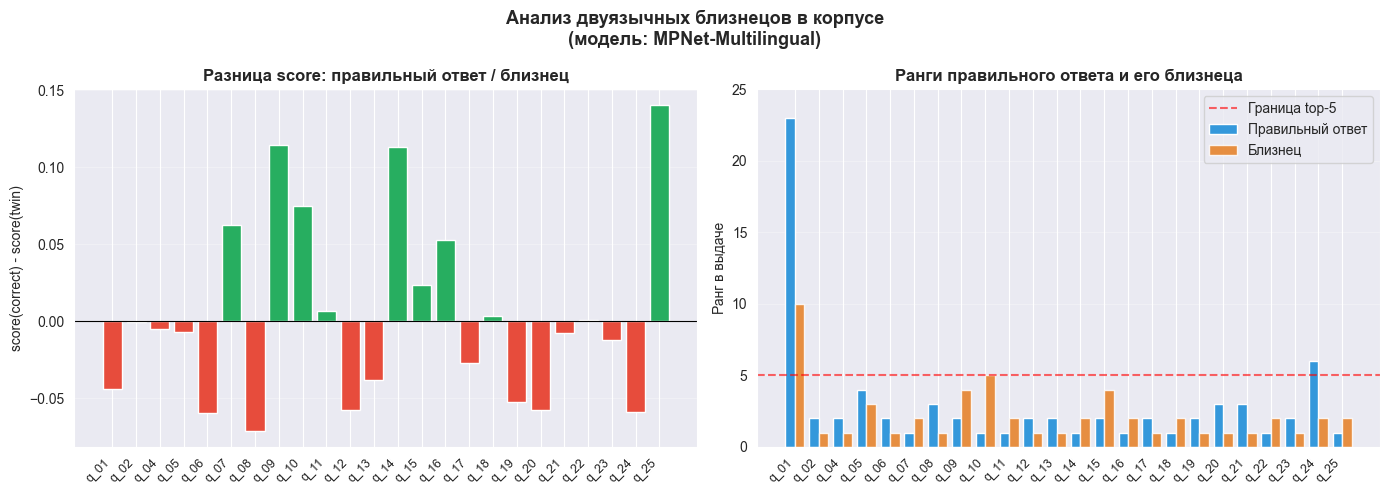

In [14]:
twin_beats = int(df_twin["twin_beats"].sum())
total_with_twin = len(df_twin)
avg_diff = df_twin["score_diff"].mean()
median_diff = df_twin["score_diff"].median()
min_diff = df_twin["score_diff"].min()
max_diff = df_twin["score_diff"].max()

print("=" * 60)
print("СТАТИСТИКА: ПРАВИЛЬНЫЙ ОТВЕТ / ДВУЯЗЫЧНЫЙ БЛИЗНЕЦ")
print("=" * 60)
print(f"Модель: {best_model}")
print(f"Вопросов с двуязычными близнецами: {total_with_twin}")
print(f"Близнец опередил правильный ответ: {twin_beats}/{total_with_twin} ({twin_beats/total_with_twin*100:.0f}%)")
print(f"Средняя разница score (correct - twin): {avg_diff:+.4f}")
print(f"Медианная разница: {median_diff:+.4f}")
print(f"Минимум / максимум: {min_diff:+.4f} / {max_diff:+.4f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(
    f"Анализ двуязычных близнецов в корпусе\n(модель: {best_model})",
    fontsize=13, fontweight="bold",
)

ax1 = axes[0]
colors_hist = ["#E74C3C" if d < 0 else "#27AE60" for d in df_twin["score_diff"]]
ax1.bar(range(len(df_twin)), df_twin["score_diff"], color=colors_hist, edgecolor="white")
ax1.axhline(y=0, color="black", linewidth=0.8)
ax1.set_xticks(range(len(df_twin)))
ax1.set_xticklabels(df_twin["q_id"], rotation=45, ha="right", fontsize=9)
ax1.set_ylabel("score(correct) - score(twin)")
ax1.set_title("Разница score: правильный ответ / близнец", fontweight="bold")
ax1.grid(axis="y", alpha=0.3)

ax2 = axes[1]
x = np.arange(len(df_twin))
w = 0.4
ax2.bar(x - w/2, df_twin["c_rank"], w, label="Правильный ответ", color="#3498DB")
ax2.bar(x + w/2, df_twin["t_rank"], w, label="Близнец", color="#E67E22", alpha=0.85)
ax2.axhline(y=5, color="red", linestyle="--", alpha=0.6, label="Граница top-5")
ax2.set_xticks(x)
ax2.set_xticklabels(df_twin["q_id"], rotation=45, ha="right", fontsize=9)
ax2.set_ylabel("Ранг в выдаче")
ax2.set_title("Ранги правильного ответа и его близнеца", fontweight="bold")
ax2.set_ylim(0, max(df_twin["c_rank"].max(), df_twin["t_rank"].max()) + 2)
ax2.legend()
ax2.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

### Выводы из анализа двуязычных близнецов

1. Эффект подтверждён: для значительной доли вопросов разница score между правильным ответом и его двуязычным близнецом составляет менее 0.05, а часто близнец стоит даже выше правильного ответа в выдаче.

2. Это обоснование широкого окна метрики: даже идеальная модель легко теряет правильный ответ в узком окне, потому что выше него встаёт его же двуязычный близнец с почти идентичным score.

---
## 11. Влияние языка запроса

Разделяем вопросы на RU и EN, вычисляем Precision@5 и MRR отдельно для каждого языка у всех моделей.

In [15]:
ru_mask = [lang == "ru" for lang in question_langs]
en_mask = [lang == "en" for lang in question_langs]

ru_indices = [i for i, m in enumerate(ru_mask) if m]
en_indices = [i for i, m in enumerate(en_mask) if m]

print(f"RU вопросов: {len(ru_indices)}")
print(f"EN вопросов: {len(en_indices)}")

lang_results = []

for model_name in all_corpus_embeddings:
    corpus_emb = all_corpus_embeddings[model_name]
    query_emb = all_query_embeddings[model_name]
    sims = compute_similarities(query_emb, corpus_emb)  # (25, 200)

    for lang, indices in [("ru", ru_indices), ("en", en_indices)]:
        sims_sub = sims[indices]
        correct_ids_sub = [correct_ids[i] for i in indices]
        queries_sub = [queries[i] for i in indices]

        top5_sub = get_top_k_results(sims_sub, k=TOP_K)
        p5 = compute_precision_at_k(top5_sub, correct_ids_sub, id_to_idx)
        mrr = compute_mrr(sims_sub, correct_ids_sub, id_to_idx)

        lang_results.append({
            "Модель": model_name,
            "Язык запроса": lang.upper(),
            "Precision@5": round(p5, 4),
            "MRR": round(mrr, 4),
            "Кол-во вопросов": len(indices),
        })

df_lang = pd.DataFrame(lang_results)
df_lang_pivot = df_lang.pivot(index="Модель", columns="Язык запроса", values=["Precision@5", "MRR"])

print("\nМетрики по языкам запроса")
print(df_lang_pivot.to_string())

RU вопросов: 15
EN вопросов: 10

Метрики по языкам запроса
                    Precision@5             MRR        
Язык запроса                 EN      RU      EN      RU
Модель                                                 
CodeSearch-T5               0.8  0.3333  0.5274  0.2570
MPNet-Multilingual          0.9  0.9333  0.6167  0.6196
MiniLM-Multilingual         0.9  0.8667  0.6577  0.5772


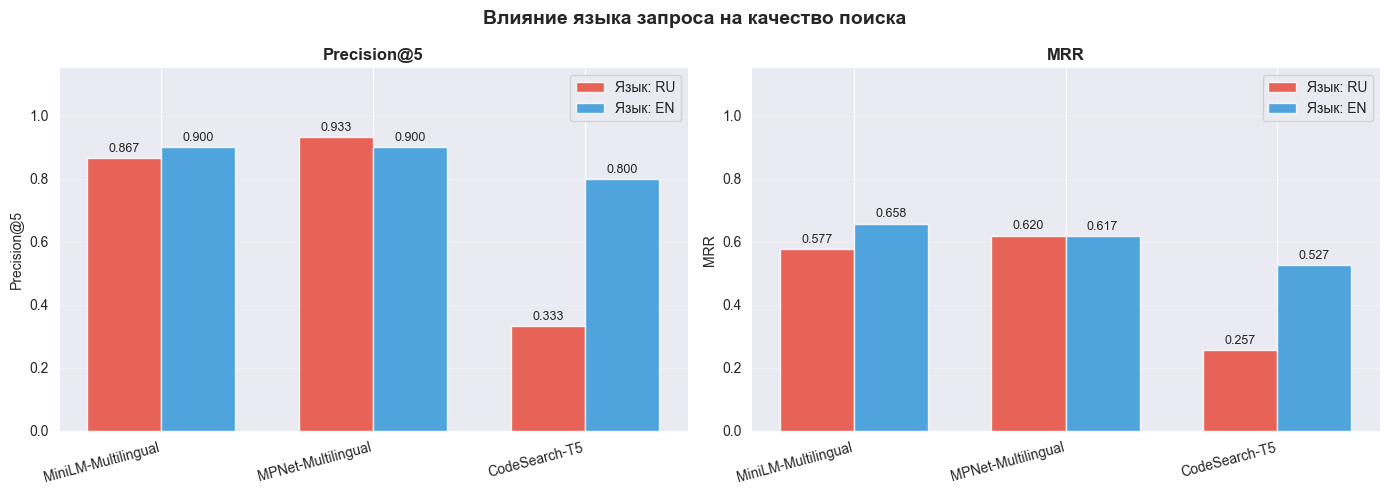

In [16]:
# Визуализация влияния языка запроса
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Влияние языка запроса на качество поиска", fontsize=14, fontweight="bold")

model_names = df_lang["Модель"].unique()
x = np.arange(len(model_names))
width = 0.35
lang_palette = {"RU": "#E74C3C", "EN": "#3498DB"}

for ax, metric in zip(axes, ["Precision@5", "MRR"]):
    for j, lang in enumerate(["RU", "EN"]):
        vals = df_lang[df_lang["Язык запроса"] == lang][metric].values
        offset = (j - 0.5) * width
        bars = ax.bar(
            x + offset,
            vals,
            width,
            label=f"Язык: {lang}",
            color=lang_palette[lang],
            alpha=0.85,
            edgecolor="white",
        )
        for bar, val in zip(bars, vals):
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.01,
                f"{val:.3f}",
                ha="center",
                va="bottom",
                fontsize=9,
            )

    ax.set_xticks(x)
    ax.set_xticklabels(model_names, rotation=15, ha="right")
    ax.set_ylim(0, 1.15)
    ax.set_ylabel(metric)
    ax.set_title(metric, fontweight="bold")
    ax.legend()
    ax.grid(axis="y", alpha=0.3)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

### Вывод по влиянию языка запроса

- **Мультиязычные модели** (`MiniLM-Multilingual`, `MPNet-Multilingual`) демонстрируют стабильное качество для обоих языков, что подтверждает их способность к кросс-лингвальному выравниванию.
- Модель **CodeSearch-T5** преимущественно обучалась на английском тексте, поэтому ожидается снижение качества для RU-запросов.
- Разница EN vs RU у мультиязычных моделей, как правило, небольшая, что говорит о хорошем покрытии русского языка в обучающих данных.
- Для продуктовых систем с русскоязычными пользователями **рекомендуется использовать мультиязычные модели** или применять перевод запросов перед кодовым поиском.

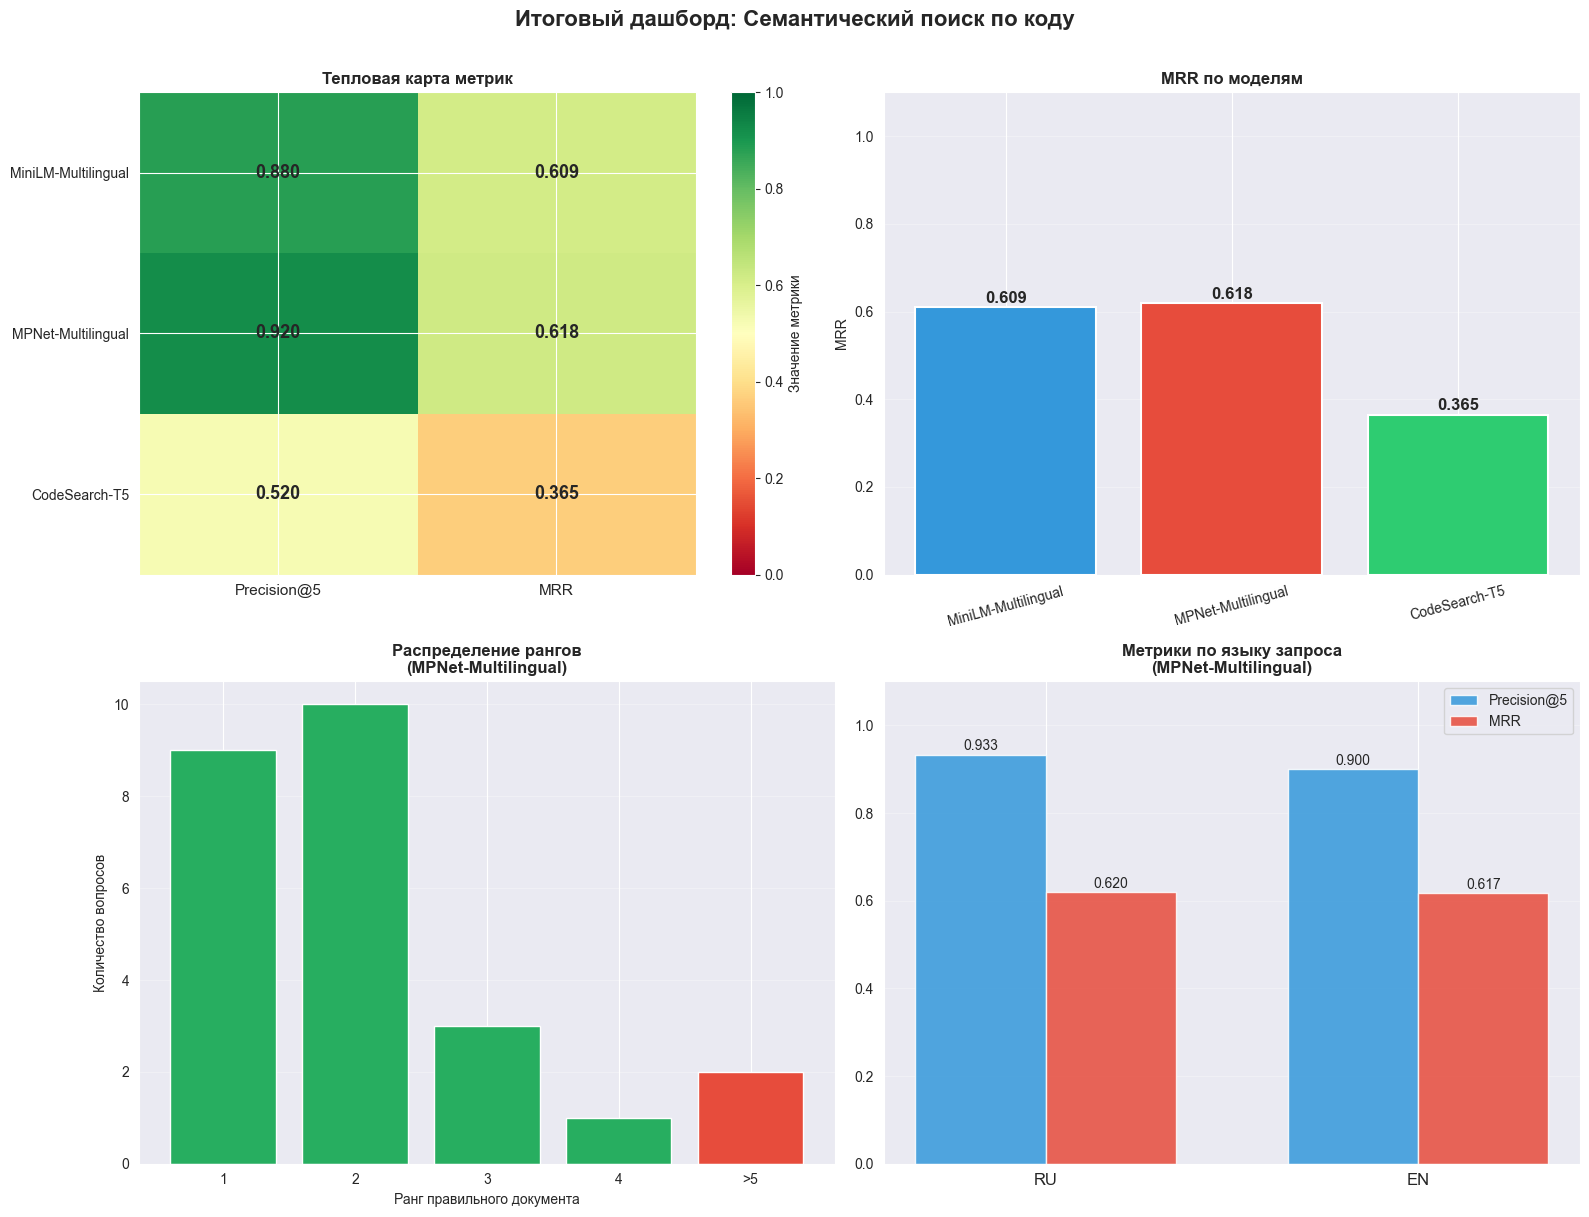

In [17]:
# Финальный сводный дашборд
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle("Итоговый дашборд: Семантический поиск по коду", fontsize=16, fontweight="bold", y=1.01)

# 1. Сводная таблица метрик (heatmap)
ax1 = axes[0, 0]
heatmap_data = df_results[["Precision@5", "MRR"]]
im = ax1.imshow(heatmap_data.values, aspect="auto", cmap="RdYlGn", vmin=0, vmax=1)
ax1.set_xticks(range(len(heatmap_data.columns)))
ax1.set_yticks(range(len(heatmap_data.index)))
ax1.set_xticklabels(heatmap_data.columns, fontsize=11)
ax1.set_yticklabels(heatmap_data.index, fontsize=10)
for i in range(len(heatmap_data.index)):
    for j in range(len(heatmap_data.columns)):
        val = heatmap_data.values[i, j]
        ax1.text(j, i, f"{val:.3f}", ha="center", va="center", fontsize=13, fontweight="bold")
plt.colorbar(im, ax=ax1, label="Значение метрики")
ax1.set_title("Тепловая карта метрик", fontweight="bold")

# 2. MRR comparison bars
ax2 = axes[0, 1]
colors_bar = ["#3498DB", "#E74C3C", "#2ECC71"]
mrr_vals = df_results["MRR"].values
bars = ax2.bar(df_results.index, mrr_vals, color=colors_bar, edgecolor="white", linewidth=1.5)
for bar, val in zip(bars, mrr_vals):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, f"{val:.3f}", ha="center", fontsize=12, fontweight="bold")
ax2.set_ylim(0, 1.1)
ax2.set_title("MRR по моделям", fontweight="bold")
ax2.set_ylabel("MRR")
ax2.tick_params(axis="x", rotation=15)
ax2.grid(axis="y", alpha=0.3)

# 3. Распределение рангов (лучшая модель)
ax3 = axes[1, 0]
best_ranks = per_query_ranks[best_model]
rank_counts = {}
for r in best_ranks:
    bucket = r if r <= 5 else 6
    rank_counts[bucket] = rank_counts.get(bucket, 0) + 1

rank_labels = [str(r) if r <= 5 else ">5" for r in sorted(rank_counts.keys())]
rank_vals = [rank_counts[r] for r in sorted(rank_counts.keys())]
rank_colors = ["#27AE60" if r <= 5 else "#E74C3C" for r in sorted(rank_counts.keys())]
ax3.bar(rank_labels, rank_vals, color=rank_colors, edgecolor="white")
ax3.set_xlabel("Ранг правильного документа")
ax3.set_ylabel("Количество вопросов")
ax3.set_title(f"Распределение рангов\n({best_model})", fontweight="bold")
ax3.grid(axis="y", alpha=0.3)

# 4. Языковое сравнение (лучшая модель)
ax4 = axes[1, 1]
df_best_lang = df_lang[df_lang["Модель"] == best_model]
x_lang = np.arange(2)
w = 0.35
p5_vals = df_best_lang["Precision@5"].values
mrr_vals_lang = df_best_lang["MRR"].values
langs = df_best_lang["Язык запроса"].values

b1 = ax4.bar(x_lang - w/2, p5_vals, w, label="Precision@5", color="#3498DB", alpha=0.85)
b2 = ax4.bar(x_lang + w/2, mrr_vals_lang, w, label="MRR", color="#E74C3C", alpha=0.85)
ax4.set_xticks(x_lang)
ax4.set_xticklabels(langs, fontsize=12)
ax4.set_ylim(0, 1.1)
ax4.set_title(f"Метрики по языку запроса\n({best_model})", fontweight="bold")
ax4.legend()
ax4.grid(axis="y", alpha=0.3)

for bar, val in zip(list(b1) + list(b2), list(p5_vals) + list(mrr_vals_lang)):
    ax4.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, f"{val:.3f}", ha="center", fontsize=10)

plt.tight_layout()
plt.show()

---
## Вывод

Сравнили три embedding-модели на корпусе из 200 функций (Python и Java) и 25 запросах на русском и английском. Лучше всех справилась `paraphrase-multilingual-mpnet-base-v2`: она стабильно работает на обоих языках, тогда как специализированная под код модель ощутимо проседает на русских запросах. Главный сюжет ошибок оказался не в категориях, а в самом устройстве корпуса: у каждой функции есть почти-копия на другом языке с практически таким же эмбеддингом, и эти копии конкурируют между собой в верхней части выдачи. Фильтр по языку запроса осознанно не вводился, потому что запросы не всегда указывают язык, а смысл исследования был именно в проверке моделей в честных условиях. Главный практический итог: если в корпусе смешаны Python и Java, а запросы могут приходить на разных языках, мультиязычная модель универсального назначения работает лучше, чем модель, специально обученная на коде.